# Kirishima elastic 2D benchmark: FD3, OPT3/4/5 and SPECFEM2D

This notebook consumes the case-specific solver-neutral bundles exported by `SimuKirishima.ipynb`. Generate `:none`, `:flat`, and `:topography` in that order. The first case has absorbing boundaries on every side; the latter two apply flat and Kirishima traction-free surfaces. SPECFEM remains an external executable and is not a flexOPT dependency.

In [1]:
import Pkg
flexopt_root = let
    marker(dir) = isfile(joinpath(dir, "Project.toml")) &&
                  isfile(joinpath(dir, "src", "commonBatchs.jl"))
    candidates = String[]
    haskey(ENV, "FLEXOPT_ROOT") && push!(candidates, ENV["FLEXOPT_ROOT"])
    directory = abspath(pwd())
    while true
        push!(candidates, directory)
        parent = dirname(directory)
        parent == directory && break
        directory = parent
    end
    index = findfirst(marker, candidates)
    isnothing(index) && error("Cannot locate flexOPT; set ENV[\"FLEXOPT_ROOT\"]")
    abspath(candidates[index])
end
Pkg.activate(flexopt_root)
using JLD2, CairoMakie, Statistics, Dates
include(joinpath(flexopt_root, "src", "specfemBenchmark.jl"))
using .specfemBenchmark
@show Base.active_project() Threads.nthreads() specfem2d_status()


  Activating project at `~/Documents/Github/flexOPT`


Base.active_project() = "/Users/nobuaki/Documents/Github/flexOPT/Project.toml"
Threads.nthreads() = 8
specfem2d_status() = (root = "/Users/nobuaki/Documents/Github/othersPackages/specfem2d", mesher = "/Users/nobuaki/Documents/Github/othersPackages/specfem2d/bin/xmeshfem2D", solver = "/Users/nobuaki/Documents/Github/othersPackages/specfem2d/bin/xspecfem2D", mesher_ready = true, solver_ready = true)


(root = "/Users/nobuaki/Documents/Github/othersPackages/specfem2d", mesher = "/Users/nobuaki/Documents/Github/othersPackages/specfem2d/bin/xmeshfem2D", solver = "/Users/nobuaki/Documents/Github/othersPackages/specfem2d/bin/xspecfem2D", mesher_ready = true, solver_ready = true)

## Load the common numerical experiment

The bundle fixes the physical model, source, receivers and FD/OPT traces. This prevents accidental comparison of different grids, source frequencies or surface definitions.

In [2]:
availableSurfaceCases = (:none, :flat, :topography)
selectedSurfaceCase = :flat # heterogeneous full-space control first
selectedSurfaceCase in availableSurfaceCases || error(
    "selectedSurfaceCase must be :none, :flat or :topography")
bundlePath = joinpath(flexopt_root, "data",
    "KirishimaElastic2D_$(selectedSurfaceCase).jld2")
isfile(bundlePath) || error("Generate the $(selectedSurfaceCase) bundle in SimuKirishima.ipynb first")
benchmark = load(bundlePath)
@show benchmark["free_surface_case"] size(benchmark["vp"])
bundleΔx = minimum(diff(benchmark["x"]))
bundleΔz = minimum(diff(benchmark["z"]))
@show bundleΔx bundleΔz
bundleΔx <= 100.0 && bundleΔz <= 100.0 || @warn(
    "This is an older coarse bundle; rerun SimuKirishima to obtain the 100 m 2D grid")
@assert Symbol(benchmark["free_surface_case"]) === selectedSurfaceCase
@assert size(benchmark["vp"]) == size(benchmark["vs"]) == size(benchmark["rho"])
@assert length(benchmark["surface_z"]) == length(benchmark["x"])


benchmark["free_surface_case"] = :flat

┌ Warning: This is an older coarse bundle; rerun SimuKirishima to obtain the 100 m 2D grid
└ @ Main In[2]:13



size(benchmark["vp"]) = (401, 211)
bundleΔx = 200.0
bundleΔz = 200.0


In [3]:
# SPECFEM's tomography file is rectangular although the spectral mesh ends at
# the free surface. Fill the unused samples above a topographic interface with
# the shallowest valid solid value; they are never sampled by the mesh.
vpSPECFEM = copy(benchmark["vp"])
vsSPECFEM = copy(benchmark["vs"])
rhoSPECFEM = copy(benchmark["rho"])
for ix in axes(vpSPECFEM, 1)
    valid = findall((@view vsSPECFEM[ix, :]) .> 0)
    isempty(valid) && error("column $ix contains no elastic material")
    top = last(valid)
    for field in (vpSPECFEM, vsSPECFEM, rhoSPECFEM)
        field[ix, top+1:end] .= field[ix, top]
    end
end
@assert minimum(vpSPECFEM) > 0
@assert minimum(vsSPECFEM) > 0
@assert minimum(rhoSPECFEM) > 0


## Generate and run the independent SPECFEM2D case

The generated case lives under `flexOPT/data/specfem2d_benchmarks`; the external SPECFEM checkout is never modified.

In [4]:
caseName = "Kirishima_$(selectedSurfaceCase)"
caseDirectory = joinpath(flexopt_root, "data", "specfem2d_benchmarks", caseName)
dxBenchmark = minimum(diff(benchmark["x"]))
dzBenchmark = minimum(diff(benchmark["z"]))
dtSPECFEM = 0.15 * min(dxBenchmark, dzBenchmark) / maximum(vpSPECFEM)
specfemCase = prepare_specfem2d_case(
    caseDirectory,
    benchmark["x"], benchmark["z"],
    vpSPECFEM, vsSPECFEM, rhoSPECFEM,
    benchmark["surface_z"];
    source=benchmark["source"],
    receivers=benchmark["receiver_x"],
    duration=benchmark["duration"],
    dt=dtSPECFEM,
    f0=benchmark["source_frequency"],
    source_factor=benchmark["source_force_amplitude"],
    source_angle=0.0,  # vertical force in SPECFEM2D
    receiver_z=mean(benchmark["receiver_z"]),
    free_surface=selectedSurfaceCase !== :none,
)
@show specfemCase.case_directory dtSPECFEM


specfemCase.case_directory = "/Users/nobuaki/Documents/Github/flexOPT/data/specfem2d_benchmarks/Kirishima_flat"
dtSPECFEM = 0.0037158563104352734


0.0037158563104352734

In [5]:
# Set false when inspecting an already completed case.
runSPECFEM2D = true
specfemTimingPath = joinpath(specfemCase.case_directory,
    "flexopt_wall_timing.jld2")
if runSPECFEM2D
    specfemRun = run_specfem2d_case(specfemCase.case_directory)
    jldsave(specfemTimingPath;
        mesher_wall_time_s=specfemRun.mesher_wall_time_s,
        solver_wall_time_s=specfemRun.solver_wall_time_s,
        total_wall_time_s=specfemRun.total_wall_time_s,
        measured_at=string(Dates.now()))
else
    specfemRun = (output=specfemCase.output,)
end
specfemTiming = isfile(specfemTimingPath) ? load(specfemTimingPath) : nothing
@show specfemRun.output specfemTiming


specfemRun.output = "/Users/nobuaki/Documents/Github/flexOPT/data/specfem2d_benchmarks/Kirishima_flat/OUTPUT_FILES"
specfemTiming = Dict{String, Any}("total_wall_time_s" => 38.959162375, "solver_wall_time_s" => 38.840486417, "measured_at" => "2026-08-07T11:28:23.788", "mesher_wall_time_s" => 0.118675958)


Dict{String, Any} with 4 entries:
  "total_wall_time_s"  => 38.9592
  "solver_wall_time_s" => 38.8405
  "measured_at"        => "2026-08-07T11:28:23.788"
  "mesher_wall_time_s" => 0.118676

## Compare surface velocity traces

Each trace is interpolated onto a common time interval for the metrics. Correlation diagnoses phase/polarity; the relative error is computed after one optimal scalar amplitude correction, so it does not hide waveform differences.

(station = 1, x_km = -20.0, safe_window = (start = 0.0, stop = 5.586656192782236), metrics = (FD3 = (correlation = 0.14726873962445486, relative_error = 0.9890965161850608, optimal_amplitude = 0.046086773070148884, relative_rmse = 3.2047617016271603, bias = 0.0005236474549386684, error_variance = 0.004165544057273245), OPT3 = (correlation = -0.05930531331106866, relative_error = 0.9982398909145416, optimal_amplitude = -0.3057401046125057, relative_rmse = 1.0298739246386541, bias = 5.527652235405138e-5, error_variance = 0.00042999525656692116)))

(station = 2, x_km = -10.0, safe_window = (start = 0.0, stop = 6.699271576444393), metrics = (FD3 = (correlation = -0.143736964353048, relative_error = 0.9896159280643027, optimal_amplitude = -0.050619198848911744, relative_rmse = 3.143167609354959, bias = -0.00014959628471291437, error_variance = 0.012131645693894652), OPT3 = (correlation = 0.35267768835558566, relative_error = 0.9357448627356502, optimal_amplitude = 0.5228290895110848, relative_rmse = 0.9895584179408757, bias = 4.346156606128219e-5, error_variance = 0.001205702847058545)))

(station = 3, x_km = 0.0, safe_window = (start = 0.0, stop = 7.812497536327527), metrics = (FD3 = (correlation = 0.08790587529763894, relative_error = 0.9961287853928106, optimal_amplitude = 0.024774642253607825, relative_rmse = 3.6009198281914148, bias = -0.00047102694967179464, error_variance = 0.004969804605214131), OPT3 = (correlation = -0.1909425295539945, relative_error = 0.9816012176069884, optimal_amplitude = -0.9790932684815395, relative_rmse = 1.05475500041996, bias = -1.0295051215451917e-5, error_variance = 0.0004284027553470659)))

(station = 4, x_km = 10.0, safe_window = (start = 0.0, stop = 8.92610562994052), metrics = (FD3 = (correlation = 0.09226016174107085, relative_error = 0.9957349358918323, optimal_amplitude = 0.013066388877264268, relative_rmse = 7.039543055401011, bias = 0.0003195553142239911, error_variance = 0.0024553319040180764), OPT3 = (correlation = -0.09012510316079587, relative_error = 0.9959304522808086, optimal_amplitude = -0.3898504416683937, relative_rmse = 1.046482809997365, bias = -2.5157589307592244e-5, error_variance = 5.4588431581927985e-5)))

(station = 5, x_km = 20.0, safe_window = (start = 0.0, stop = 7.812497536327527), metrics = (FD3 = (correlation = -0.012922357612971164, relative_error = 0.9999165028509744, optimal_amplitude = -0.006238482760610579, relative_rmse = 2.312613261216893, bias = -5.3926687589770614e-5, error_variance = 3.913567820842631e-6), OPT3 = (correlation = 0.4648891619983372, relative_error = 0.8853688875584478, optimal_amplitude = 2.0676187898820855, relative_rmse = 0.9173737277765939, bias = -7.390254241301551e-6, error_variance = 6.19187789979663e-7)))

(FD3 = (mean_correlation = 0.034155090939429096, rms_relative_error = 0.9941071607955941, maximum_relative_error = 0.9999165028509744, mean_raw_relative_rmse = 3.860201091158287), OPT3 = (mean_correlation = 0.09543878086561278, rms_relative_error = 0.9603538734438986, maximum_relative_error = 0.9982398909145416, mean_raw_relative_rmse = 1.0076087761546897))

┌ Warning: Timing unavailable: regenerate SimuKirishima and run SPECFEM once
└ @ Main In[6]:125


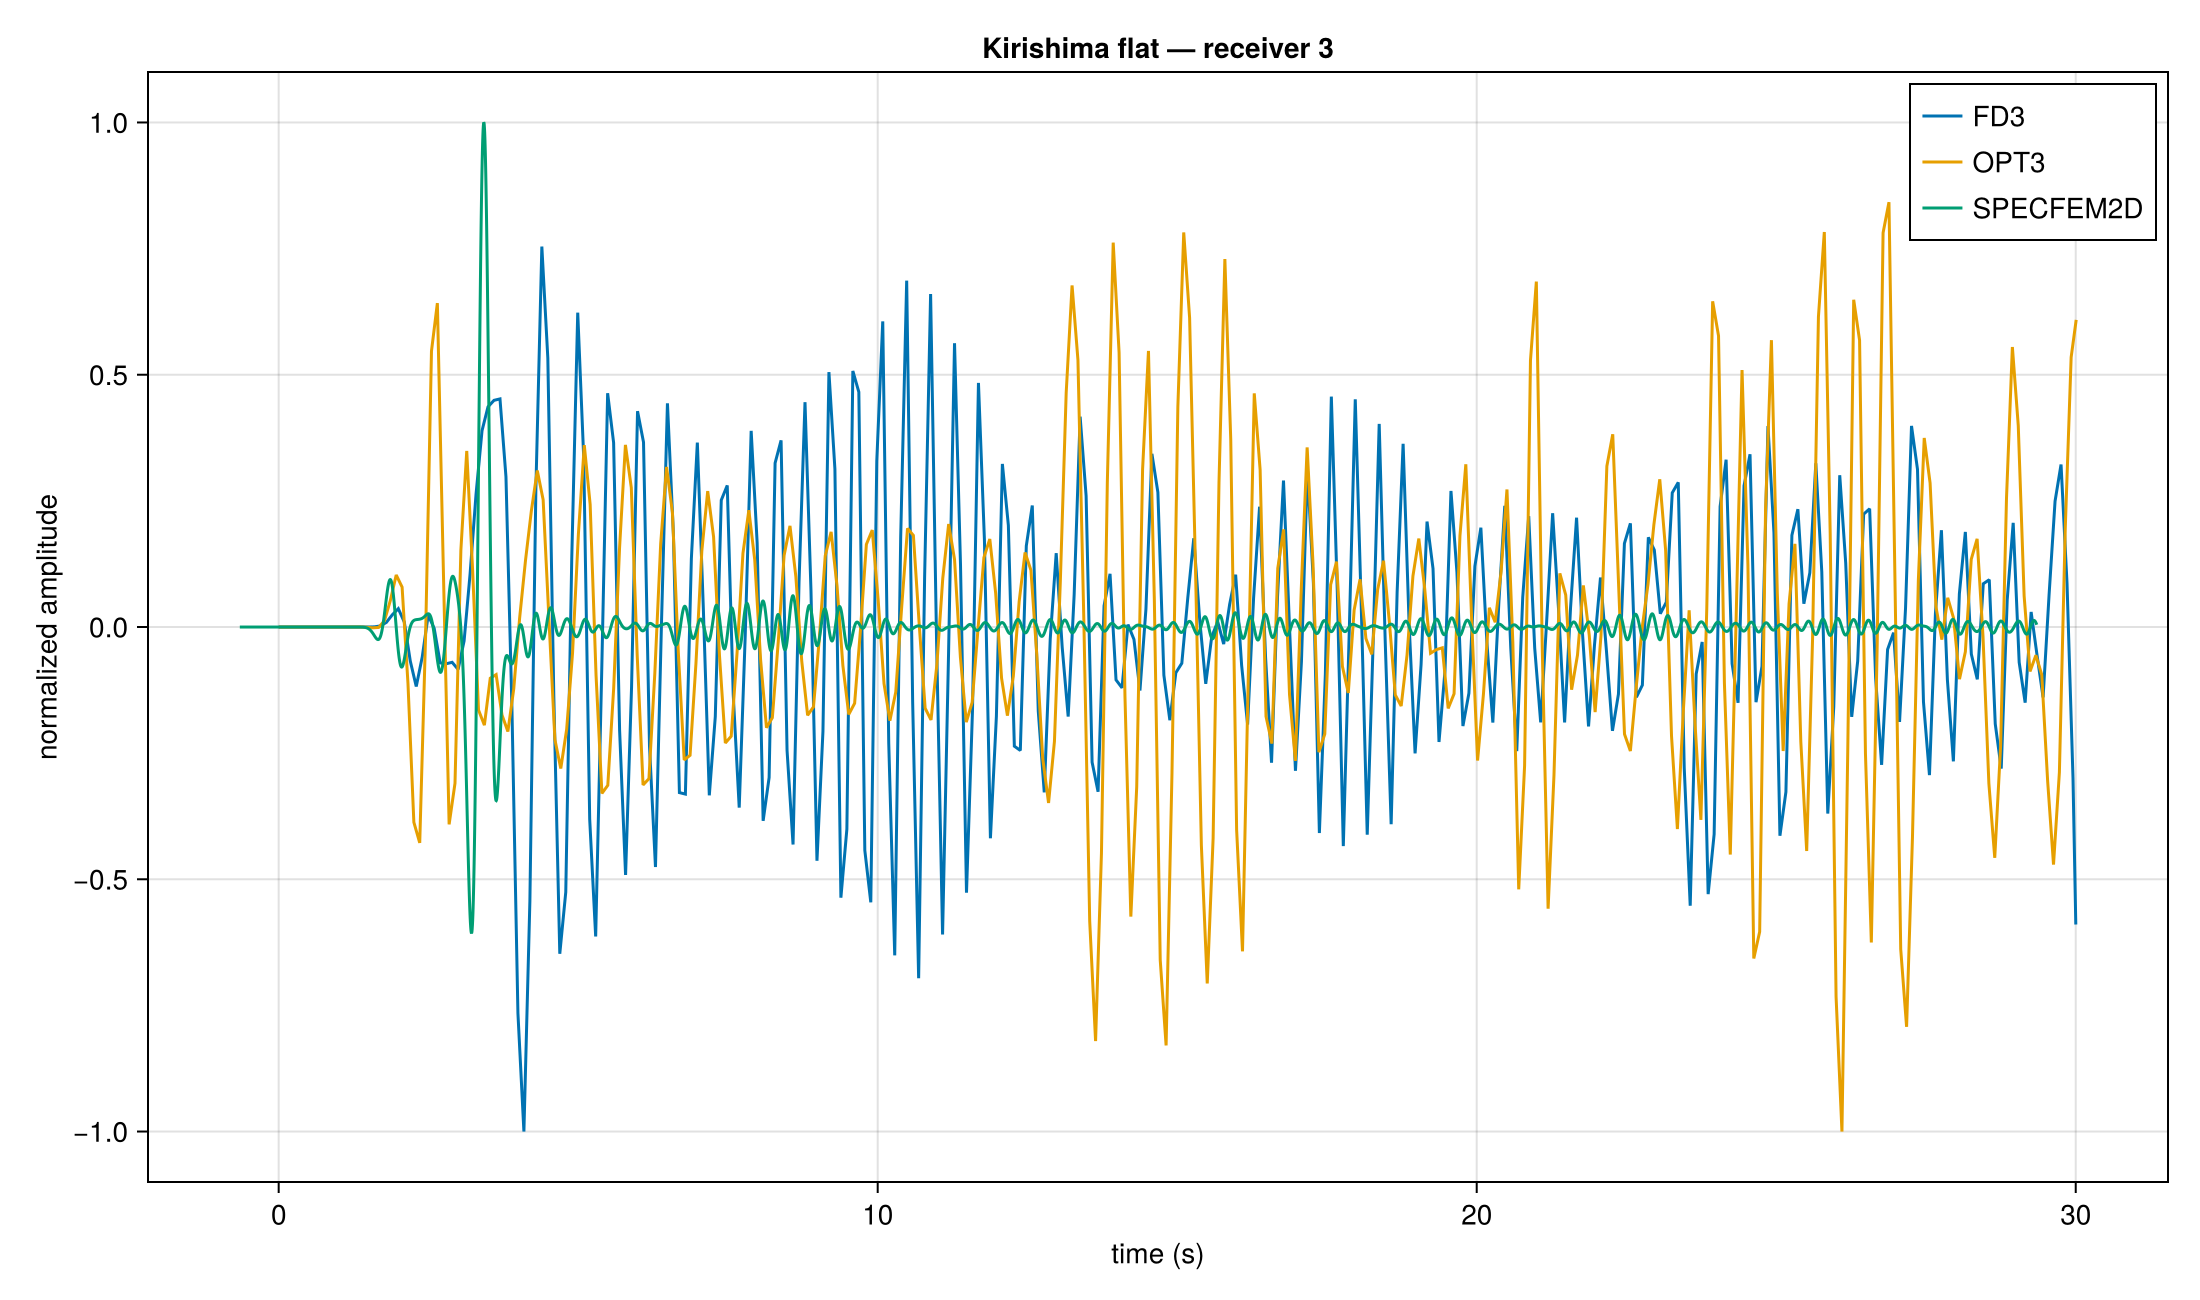

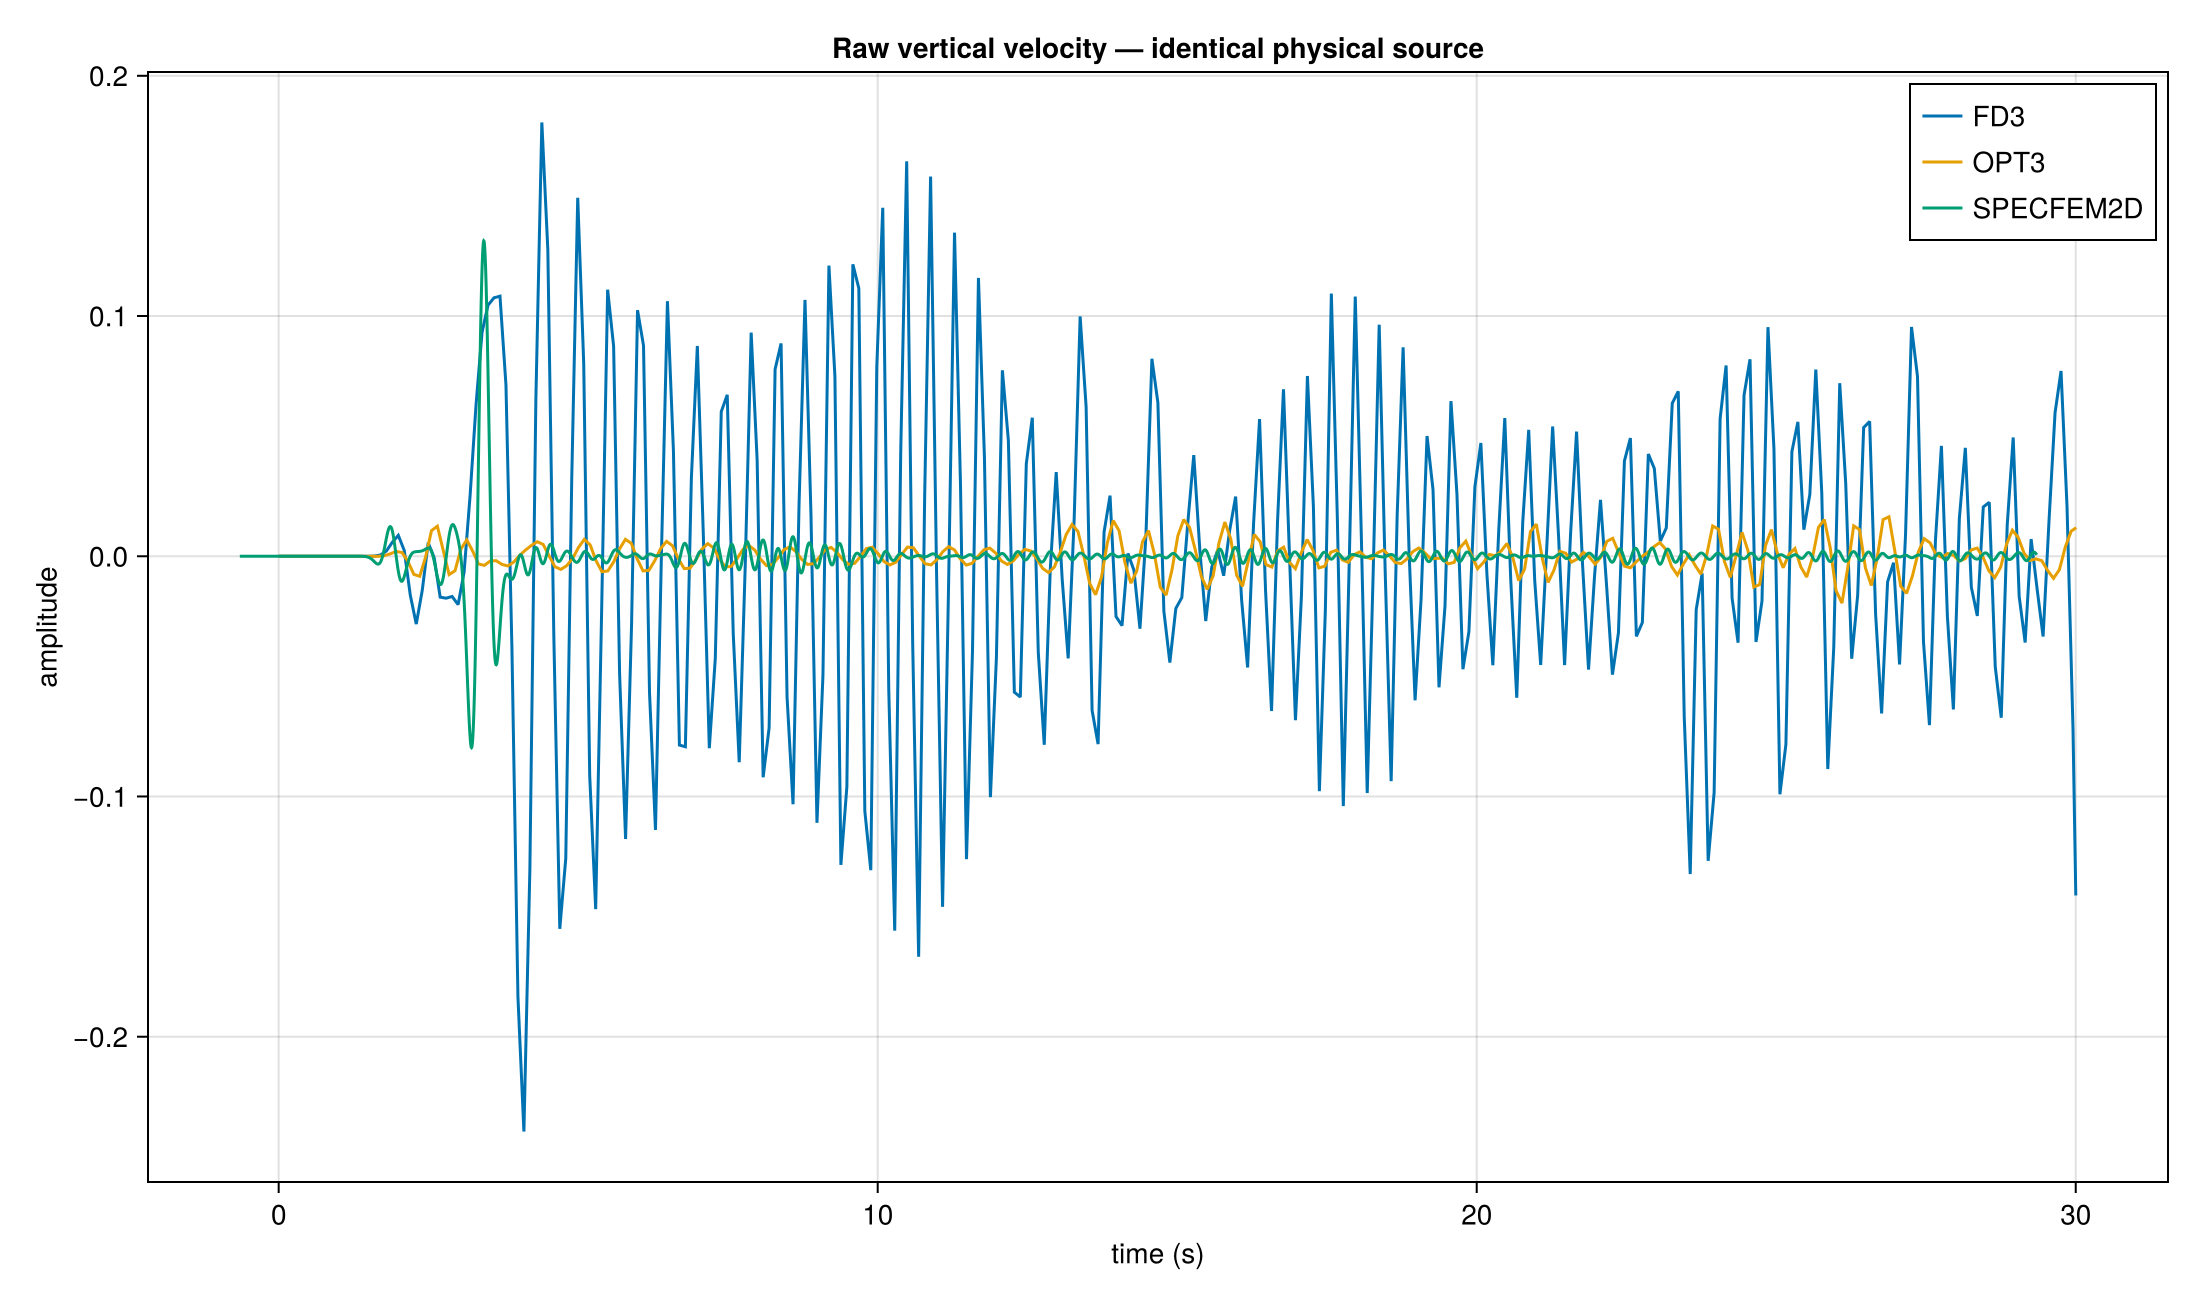

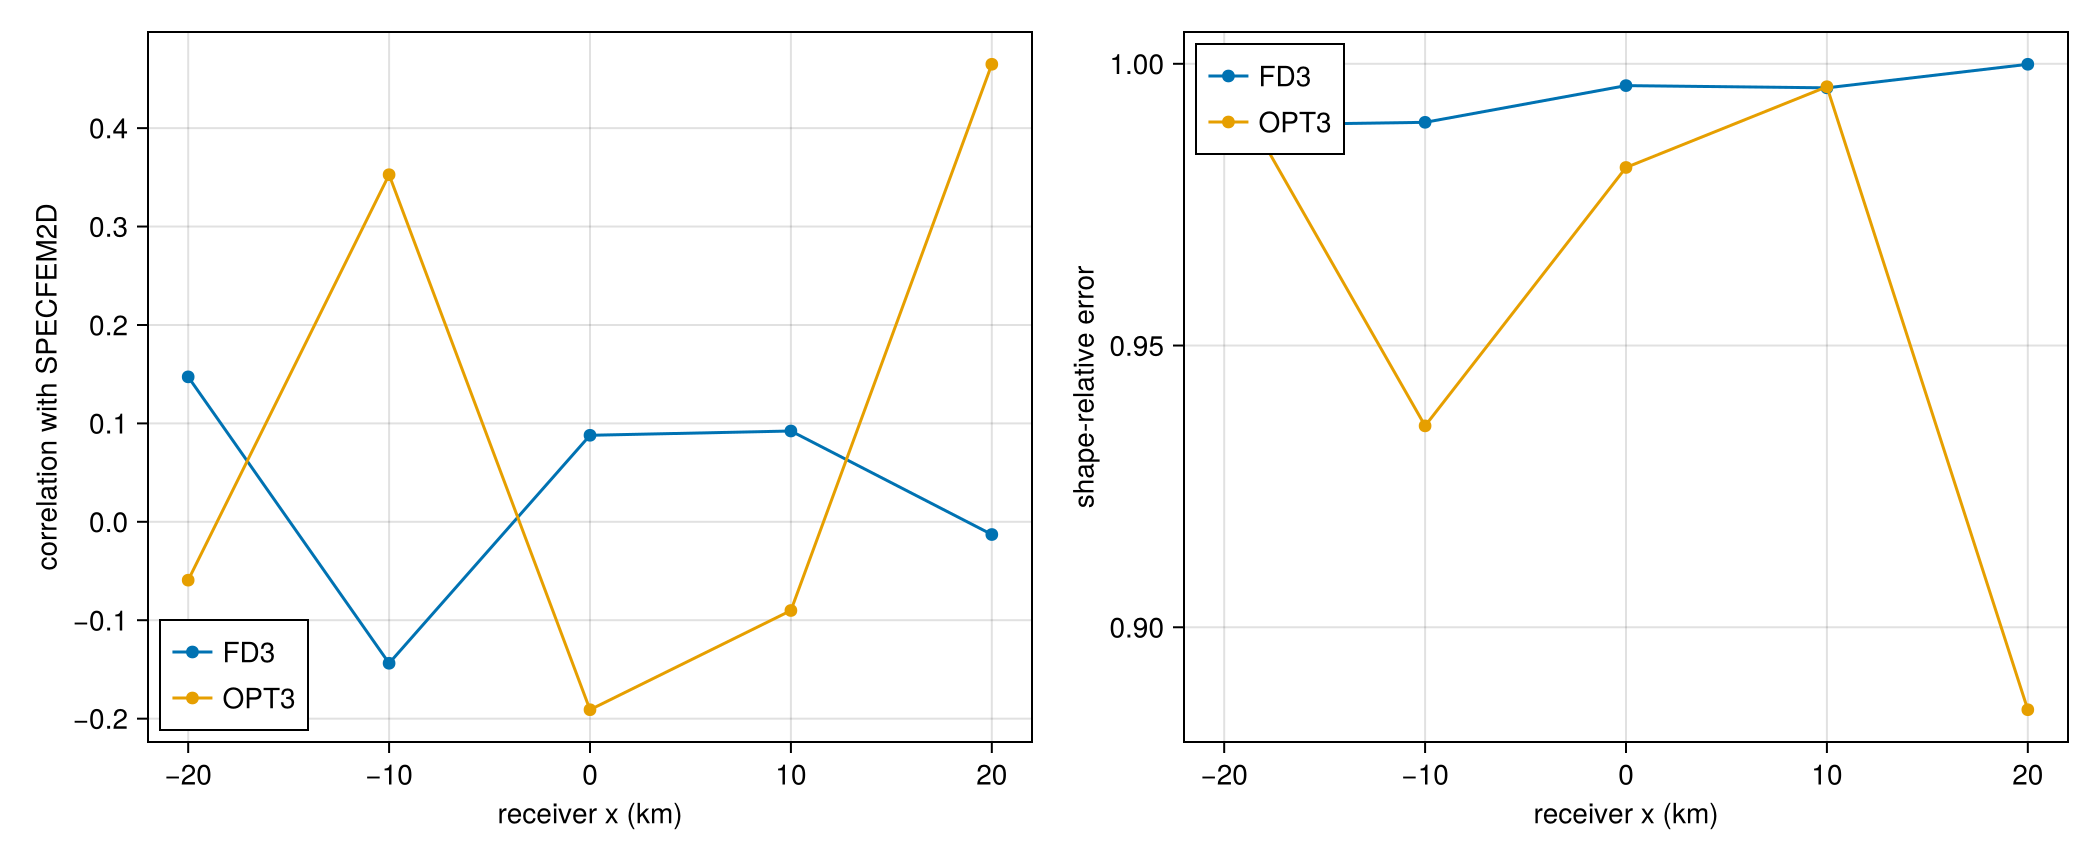

In [6]:
# Prefixes can be CXZ, FXZ, etc. depending on SPECFEM's channel convention;
# select the physical vertical component and order it by station id.
specfemVerticalFiles = find_specfem2d_traces(
    specfemRun.output; component=:z)
@assert length(specfemVerticalFiles) == length(benchmark["receiver_x"])
# Read all SPECFEM stations once. Every numerical table uses the native
# (time, station) convention exported by SimuKirishima.
specfemTraces = read_specfem2d_trace.(specfemVerticalFiles)

value_from(container, name::Symbol) = hasproperty(container, name) ?
    getproperty(container, name) : container[String(name)]

function solver_traces_at_station(benchmark, station)
    traces = (
        FD3=(time=Float64.(benchmark["fd_time"]),
            values=Float64.(benchmark["fd_traces"][:, station])),
        OPT3=(time=Float64.(benchmark["opt_time"]),
            values=Float64.(benchmark["opt_traces"][:, station])),
    )
    if haskey(benchmark, "convfd_time") &&
       haskey(benchmark, "convfd_traces")
        traces = merge(traces, (convFD3=(
            time=Float64.(benchmark["convfd_time"]),
            values=Float64.(benchmark["convfd_traces"][:, station])),))
    end
    # New bundles may contain OPT4/OPT5 without changing this notebook.
    if haskey(benchmark, "opt_higher_traces")
        for (rawName, data) in pairs(benchmark["opt_higher_traces"])
            name = Symbol(rawName)
            trace = (time=Float64.(value_from(data, :time)),
                values=Float64.(value_from(data, :traces)[:, station]))
            traces = merge(traces, NamedTuple{(name,)}((trace,)))
        end
    end
    return traces
end

function crop_trace(trace, startTime, stopTime)
    keep = (trace.time .>= startTime) .& (trace.time .<= stopTime)
    count(keep) >= 3 || error("insufficient samples in safe window")
    (time=trace.time[keep], values=trace.values[keep])
end

# Conservative first arrival from a lateral/bottom artificial boundary,
# obtained by the image-source construction. The physical free-surface
# reflection is intentionally retained.
function artificial_boundary_safe_stop(benchmark, station; safety=0.90)
    source = benchmark["source"]
    sx, sz = value_from(source, :x), value_from(source, :z)
    rx = benchmark["receiver_x"][station]
    rz = benchmark["receiver_z"][station]
    xmin, xmax = extrema(benchmark["x"])
    zmin = minimum(benchmark["z"])
    imageDistances = (
        hypot(rx - (2xmin - sx), rz - sz),
        hypot(rx - (2xmax - sx), rz - sz),
        hypot(rx - sx, rz - (2zmin - sz)),
    )
    min(benchmark["duration"],
        safety * minimum(imageDistances) / maximum(benchmark["vp"]))
end

stationErrorMetrics = map(eachindex(specfemTraces)) do station
    candidates = solver_traces_at_station(benchmark, station)
    reference = specfemTraces[station]
    startTime = maximum(vcat(first(reference.time),
        [first(trace.time) for trace in values(candidates)]))
    stopTime = minimum(vcat(artificial_boundary_safe_stop(benchmark, station),
        last(reference.time),
        [last(trace.time) for trace in values(candidates)]))
    referenceSafe = crop_trace(reference, startTime, stopTime)
    metrics = map(candidates) do trace
        full = waveform_metrics(referenceSafe,
            crop_trace(trace, startTime, stopTime); samples=1001)
        (correlation=full.correlation,
         relative_error=full.relative_error,
         optimal_amplitude=full.optimal_amplitude,
         relative_rmse=full.relative_rmse,
         bias=full.bias, error_variance=full.error_variance)
    end
    (station=station, x_km=benchmark["receiver_x"][station] / 1e3,
        safe_window=(start=startTime, stop=stopTime), metrics=metrics)
end
foreach(display, stationErrorMetrics)

methodNames = keys(first(stationErrorMetrics).metrics)
globalErrorMetrics = NamedTuple{methodNames}(map(methodNames) do method
    results = [getproperty(row.metrics, method) for row in stationErrorMetrics]
    (mean_correlation=mean(getproperty.(results, :correlation)),
     rms_relative_error=sqrt(mean(abs2, getproperty.(results, :relative_error))),
     maximum_relative_error=maximum(getproperty.(results, :relative_error)),
     mean_raw_relative_rmse=mean(getproperty.(results, :relative_rmse)))
end)
display(globalErrorMetrics)

# Fair cross-code timing: propagation/solver wall time only. SPECFEM's
# mesher time is reported separately and excluded from the speed ratio.
timingComparison = nothing
timingFigure = nothing
if haskey(benchmark, "solver_wall_times") && !isnothing(specfemTiming)
    juliaWallTimes = Dict(Symbol(name) => Float64(value)
        for (name, value) in benchmark["solver_wall_times"])
    specfemSolverTime = Float64(specfemTiming["solver_wall_time_s"])
    allWallTimes = merge(juliaWallTimes,
        Dict(:SPECFEM2D => specfemSolverTime))
    simulatedDuration = Float64(benchmark["duration"])
    timingComparison = Dict(method => (
        wall_time_s=wallTime,
        speed_relative_to_SPECFEM=specfemSolverTime / wallTime,
        wall_seconds_per_simulated_second=wallTime / simulatedDuration)
        for (method, wallTime) in allWallTimes)
    display((solver=timingComparison,
        specfem_mesher_wall_time_s=specfemTiming["mesher_wall_time_s"],
        specfem_total_wall_time_s=specfemTiming["total_wall_time_s"],
        julia_context=get(benchmark, "solver_runtime_context", nothing)))
    timingMethods = collect(keys(allWallTimes))
    timingValues = [allWallTimes[name] for name in timingMethods]
    timingFigure = Figure(size=(760, 430))
    timingAxis = Axis(timingFigure[1, 1]; ylabel="solver wall time (s)",
        title="Identical physical duration: $(simulatedDuration) s",
        xticks=(eachindex(timingMethods), string.(timingMethods)))
    barplot!(timingAxis, eachindex(timingValues), timingValues)
    display(timingFigure)
else
    @warn "Timing unavailable: regenerate SimuKirishima and run SPECFEM once"
end

receiver = cld(length(specfemTraces), 2)
middleTraces = merge(solver_traces_at_station(benchmark, receiver),
    (SPECFEM2D=specfemTraces[receiver],))
benchmarkPlot = plot_solver_benchmark(middleTraces;
    title="Kirishima $(benchmark["free_surface_case"]) — receiver $(receiver)")
display(benchmarkPlot.figure)
rawAmplitudePlot = plot_solver_benchmark(middleTraces; normalize=false,
    title="Raw vertical velocity — identical physical source")
display(rawAmplitudePlot.figure)

errorFigure = Figure(size=(1050, 430))
correlationAxis = Axis(errorFigure[1, 1]; xlabel="receiver x (km)",
    ylabel="correlation with SPECFEM2D")
relativeAxis = Axis(errorFigure[1, 2]; xlabel="receiver x (km)",
    ylabel="shape-relative error")
for method in methodNames
    rows = [getproperty(item.metrics, method) for item in stationErrorMetrics]
    xs = getproperty.(stationErrorMetrics, :x_km)
    scatterlines!(correlationAxis, xs, getproperty.(rows, :correlation);
        marker=:circle, label=string(method))
    scatterlines!(relativeAxis, xs, getproperty.(rows, :relative_error);
        marker=:circle, label=string(method))
end
axislegend(correlationAxis; position=:lb)
axislegend(relativeAxis; position=:lt)
errorFigure


## Interpretation order

1. Start with `:flat`: disagreement here indicates source normalization, temporal convention or numerical dispersion—not topography.
2. Compare arrival times before amplitudes.
3. Repeat with `:topography` only after the flat case is consistent.
4. SPECFEM is a high-order reference, not an automatic ground truth: verify its mesh resolution and reported minimum period in `OUTPUT_FILES`.